# Assignment 06 — Part 0: Concepts, functions and operators of an RNN

Requirement R1: everything needed to read the scratch, Keras and PyTorch implementations in `ec_retail.ipynb` and `st_sp500.ipynb`.
Each idea gets a small **worked example with numbers**, and every formula is **checked** against NumPy or PyTorch (the cell fails if the check fails).

| § | Topic |
|---|---|
| 1 | Sequences as data: windows, tensors `(N, T, F)`, many-to-one vs many-to-many |
| 2 | The operators: matrix product, element-wise product, `tanh`, `sigmoid`, softmax, and their derivatives |
| 3 | One RNN step, unrolling, weight sharing |
| 4 | Back-propagation through time (BPTT) |
| 5 | Vanishing and exploding gradients, gradient clipping |
| 6 | LSTM and GRU gates |
| 7 | One layer, three names: scratch ↔ Keras ↔ PyTorch |

In [1]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, torch, torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
sns.set_theme(style="whitegrid"); np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42); torch.manual_seed(42)

## 1. Sequences as data

A feed-forward network sees one fixed-length vector. Time-series data are **ordered**: the same value means something different depending on what came before. An RNN reads the observations one step at a time and keeps a memory.

**Supervised framing with a sliding window.** From a series $s_1,s_2,\dots$ with window length $T$, every window $x=(s_{i},\dots,s_{i+T-1})$ is an input and the next value $s_{i+T}$ is its target. With $F$ features per step the whole data set is a tensor

$$X\in\mathbb R^{N\times T\times F},\qquad y\in\mathbb R^{N}.$$

Example: the series $[10,12,11,15,14,18]$ with $T=3$ gives $N=3$ windows: `[10,12,11]→15`, `[12,11,15]→14`, `[11,15,14]→18`.

**Many-to-one** (used in this assignment): read $T$ steps, emit one prediction from the last state. **Many-to-many**: emit an output at every step (e.g. tagging each word); same recurrence, a head applied to every $h_t$ instead of only $h_T$.

In [2]:
s = np.array([10, 12, 11, 15, 14, 18], dtype=float); T_ = 3
X_demo = sliding_window_view(s[:-1], T_)[:, :, None]      # (N, T, F=1); last value never appears as an input
y_demo = s[T_:]
print("X shape (N, T, F) =", X_demo.shape, "| y =", y_demo)
for x_, y_ in zip(X_demo[:, :, 0], y_demo): print(x_, "->", y_)
assert X_demo.shape == (3, 3, 1) and list(y_demo) == [15, 14, 18]

# Chronological split: never shuffle across time. 70/15/15 of the *target* positions
n = 20; idx = np.arange(n); tr, va, te = idx[:int(.7 * n)], idx[int(.7 * n):int(.85 * n)], idx[int(.85 * n):]
print("train", tr[[0, -1]], "validation", va[[0, -1]], "test", te[[0, -1]], "-> every test target is later than every train target")

X shape (N, T, F) = (3, 3, 1) | y = [15. 14. 18.]
[10. 12. 11.] -> 15.0
[12. 11. 15.] -> 14.0
[11. 15. 14.] -> 18.0
train [ 0 13] validation [14 16] test [17 19] -> every test target is later than every train target


## 2. The operators

| Operator | Definition | Role in an RNN |
|---|---|---|
| matrix product $xW$ | $(xW)_j=\sum_i x_iW_{ij}$ | mixes the $F$ inputs / $H$ state values into $H$ new values |
| element-wise (Hadamard) product $a\odot b$ | $(a\odot b)_i=a_ib_i$ | **gates**: a value in $(0,1)$ scales another value (LSTM/GRU), and the chain rule through `tanh` |
| $\tanh(z)=\dfrac{e^z-e^{-z}}{e^z+e^{-z}}$ | squashes to $(-1,1)$, $\tanh'(z)=1-\tanh^2(z)$ | the recurrence non-linearity; keeps the state bounded |
| $\sigma(z)=\dfrac1{1+e^{-z}}$ | squashes to $(0,1)$, $\sigma'=\sigma(1-\sigma)$ | gate values ("how much to let through") |
| softmax $\dfrac{e^{z_k}}{\sum_j e^{z_j}}$ | probabilities summing to 1 | output for classification (not needed for our regression heads) |

Worked numbers:
* matrix product: $x=(1,2)$, $W=\begin{pmatrix}1&0&2\\3&1&0\end{pmatrix}$ gives $xW=(1\cdot1+2\cdot3,\;1\cdot0+2\cdot1,\;1\cdot2+2\cdot0)=(7,2,2)$.
* Hadamard: $(0.9,\,0.1)\odot(4,\,4)=(3.6,\,0.4)$, a gate of 0.9 keeps 90 % of a value and 0.1 keeps 10 %.
* $\tanh(0)=0$, $\tanh(1)=0.7616$, $\tanh(3)=0.9951$ (saturates), $\tanh'(3)=1-0.9951^2=0.0099$: **a saturated unit passes almost no gradient**.

x @ W = [7. 2. 2.]
gate * value = [3.6 0.4]
tanh(0, 1, 3) = [0.     0.7616 0.9951] | tanh'(3) = 0.009866037165440211
sigmoid(0) = 0.5 | softmax([1,2,3]) = [0.09   0.2447 0.6652] sum = 0.9999999999999999


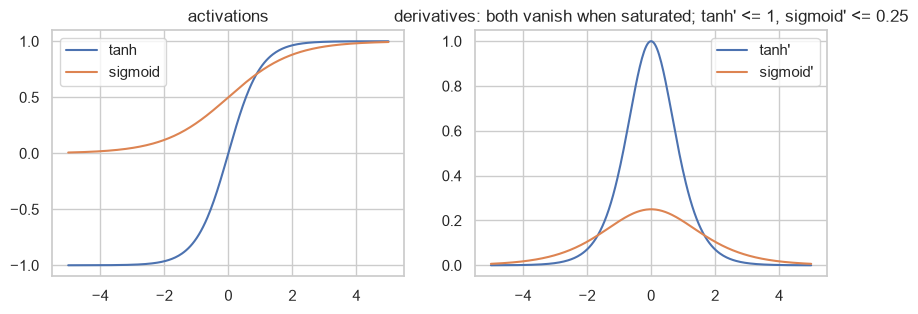

In [3]:
x = np.array([1., 2.]); W = np.array([[1, 0, 2], [3, 1, 0.]])
print("x @ W =", x @ W); assert np.allclose(x @ W, [7, 2, 2])
print("gate * value =", np.array([.9, .1]) * np.array([4., 4.])); assert np.allclose(np.array([.9, .1]) * 4, [3.6, .4])
tanh, sigmoid = np.tanh, lambda z: 1 / (1 + np.exp(-z))
softmax = lambda z: np.exp(z - z.max()) / np.exp(z - z.max()).sum()
print("tanh(0, 1, 3) =", tanh(np.array([0, 1, 3.])), "| tanh'(3) =", 1 - tanh(3.) ** 2)
print("sigmoid(0) =", sigmoid(0.), "| softmax([1,2,3]) =", softmax(np.array([1., 2, 3])), "sum =", softmax(np.array([1., 2, 3])).sum())

# derivatives checked against finite differences
z = np.linspace(-4, 4, 9); h = 1e-6
assert np.allclose((tanh(z + h) - tanh(z - h)) / (2 * h), 1 - tanh(z) ** 2, atol=1e-6)
assert np.allclose((sigmoid(z + h) - sigmoid(z - h)) / (2 * h), sigmoid(z) * (1 - sigmoid(z)), atol=1e-6)

zz = np.linspace(-5, 5, 300); fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(zz, tanh(zz), label="tanh"); ax[0].plot(zz, sigmoid(zz), label="sigmoid"); ax[0].legend(); ax[0].set(title="activations")
ax[1].plot(zz, 1 - tanh(zz) ** 2, label="tanh'"); ax[1].plot(zz, sigmoid(zz) * (1 - sigmoid(zz)), label="sigmoid'"); ax[1].legend(); ax[1].set(title="derivatives: both vanish when saturated; tanh' <= 1, sigmoid' <= 0.25")
plt.show()

## 3. One RNN step, unrolling, weight sharing

State $h_t\in\mathbb R^H$ is the memory. At every step the network combines the new input with the previous memory:

$$h_t=\tanh\big(x_tW_{xh}+h_{t-1}W_{hh}+b\big),\qquad h_0=0,\qquad \hat y=h_TW_{hy}+b_y.$$

Sizes: $W_{xh}\in\mathbb R^{F\times H}$, $W_{hh}\in\mathbb R^{H\times H}$, $b\in\mathbb R^H$, so a vanilla RNN layer has $FH+H^2+H$ parameters — **independent of $T$**, because the *same* weights are applied at every step (weight sharing). "Unrolling" means drawing the loop as $T$ copies of the same cell chained through $h$.

Worked step with $F=2,\ H=3$: $x_1=(1,\,-1)$, $h_0=0$ so only the input part matters, $z_1=x_1W_{xh}+b$. With $W_{xh}=\begin{pmatrix}0.5&-0.5&0.1\\0.2&0.3&-0.4\end{pmatrix}$, $b=0$: $z_1=(0.5-0.2,\;-0.5-0.3,\;0.1+0.4)=(0.3,\,-0.8,\,0.5)$ and $h_1=\tanh(z_1)=(0.2913,\,-0.6640,\,0.4621)$.

In [4]:
F_, H_ = 2, 3
Wxh = np.array([[.5, -.5, .1], [.2, .3, -.4]]); Whh = rng.normal(0, .5, (H_, H_)); b = np.zeros(H_)
x1 = np.array([1., -1.]); h0 = np.zeros(H_)
z1 = x1 @ Wxh + h0 @ Whh + b; h1 = np.tanh(z1)
print("z1 =", z1, "\nh1 =", h1); assert np.allclose(z1, [.3, -.8, .5]) and np.allclose(h1, [.2913, -.6640, .4621], atol=1e-4)

def rnn_forward(X, Wxh, Whh, b):                      # X: (T, F) one sequence -> all states h_1..h_T
    h, hs = np.zeros(Whh.shape[0]), []
    for x_t in X: h = np.tanh(x_t @ Wxh + h @ Whh + b); hs.append(h)
    return np.array(hs)

X3 = rng.normal(size=(3, F_)); hs = rnn_forward(X3, Wxh, Whh, b)            # unrolled for T = 3
print("states h_1..h_3:\n", hs)

# the same function in PyTorch: nn.RNN stores W_ih (H,F) and W_hh (H,H) = transposes of ours, plus TWO biases
rnn = nn.RNN(F_, H_, batch_first=True)
with torch.no_grad():
    rnn.weight_ih_l0.copy_(torch.tensor(Wxh.T)); rnn.weight_hh_l0.copy_(torch.tensor(Whh.T)); rnn.bias_ih_l0.zero_(); rnn.bias_hh_l0.zero_()
out, _ = rnn(torch.tensor(X3[None], dtype=torch.float32))
print("max |NumPy - torch.nn.RNN| =", np.abs(out[0].detach().numpy() - hs).max()); assert np.allclose(out[0].detach().numpy(), hs, atol=1e-5)

for T_ in (3, 28, 1000): print(f"T = {T_:4d}: parameters = F*H + H*H + H = {F_ * H_ + H_ * H_ + H_} (unchanged)")

z1 = [ 0.3 -0.8  0.5] 
h1 = [ 0.2913 -0.664   0.4621]
states h_1..h_3:
 [[-0.2455  0.5982 -0.4112]
 [ 0.5509 -0.641  -0.4026]
 [ 0.3917 -0.0208  0.5029]]
max |NumPy - torch.nn.RNN| = 3.189468264844231e-08
T =    3: parameters = F*H + H*H + H = 18 (unchanged)
T =   28: parameters = F*H + H*H + H = 18 (unchanged)
T = 1000: parameters = F*H + H*H + H = 18 (unchanged)


## 4. Back-propagation through time (BPTT)

Training = gradient descent on a loss, e.g. $L=(\hat y-y)^2$. Because $h_t$ depends on $h_{t-1}$, the gradient of the loss must flow **backwards through every time step**. With $z_t=x_tW_{xh}+h_{t-1}W_{hh}+b$:

$$\frac{\partial L}{\partial h_T}=2(\hat y-y)\,W_{hy}^\top,\qquad
\frac{\partial L}{\partial z_t}=\frac{\partial L}{\partial h_t}\odot(1-h_t^2),\qquad
\frac{\partial L}{\partial h_{t-1}}=\frac{\partial L}{\partial z_t}\,W_{hh}^\top .$$

Each step contributes to the shared weights, so the gradients are **sums over time**:

$$\frac{\partial L}{\partial W_{xh}}=\sum_t x_t^\top\frac{\partial L}{\partial z_t},\quad
\frac{\partial L}{\partial W_{hh}}=\sum_t h_{t-1}^\top\frac{\partial L}{\partial z_t},\quad
\frac{\partial L}{\partial b}=\sum_t\frac{\partial L}{\partial z_t}.$$

The cell below implements exactly these lines for $T=3$ and compares them with (a) finite differences and (b) PyTorch autograd.

In [5]:
Why = rng.normal(0, .5, (H_, 1)); by = np.zeros(1); y_true = 0.7
def loss_and_grads(X, Wxh, Whh, b, Why, by, y):
    T = len(X); hs = [np.zeros(Whh.shape[0])]
    for t in range(T): hs.append(np.tanh(X[t] @ Wxh + hs[-1] @ Whh + b))
    yhat = hs[-1] @ Why + by; L = float(((yhat - y) ** 2).sum())
    g = dict(Wxh=np.zeros_like(Wxh), Whh=np.zeros_like(Whh), b=np.zeros_like(b))
    gWhy = np.outer(hs[-1], 2 * (yhat - y)); gby = 2 * (yhat - y)
    dh = (2 * (yhat - y)) @ Why.T
    for t in range(T, 0, -1):
        dz = dh * (1 - hs[t] ** 2)
        g["Wxh"] += np.outer(X[t - 1], dz); g["Whh"] += np.outer(hs[t - 1], dz); g["b"] += dz
        dh = dz @ Whh.T
    return L, dict(g, Why=gWhy, by=gby)

P = dict(Wxh=Wxh, Whh=Whh, b=b, Why=Why, by=by)
L, g = loss_and_grads(X3, **P, y=y_true)
# (a) finite differences, every entry
max_err = 0
for k in P:
    for ix in np.ndindex(*P[k].shape):
        old = P[k][ix]; P[k][ix] = old + 1e-6; lp = loss_and_grads(X3, **P, y=y_true)[0]; P[k][ix] = old - 1e-6; lm = loss_and_grads(X3, **P, y=y_true)[0]; P[k][ix] = old
        max_err = max(max_err, abs(g[k][ix] - (lp - lm) / 2e-6))
print("BPTT vs finite differences, max abs error:", max_err); assert max_err < 1e-7
# (b) PyTorch autograd
tp = {k: torch.tensor(v, dtype=torch.float64, requires_grad=True) for k, v in P.items()}; h = torch.zeros(H_, dtype=torch.float64)
for t in range(3): h = torch.tanh(torch.tensor(X3[t]) @ tp["Wxh"] + h @ tp["Whh"] + tp["b"])
((h @ tp["Why"] + tp["by"] - y_true) ** 2).sum().backward()
print("BPTT vs autograd,", {k: float(np.abs(tp[k].grad.numpy() - g[k]).max()) for k in P}); assert all(np.allclose(tp[k].grad.numpy(), g[k]) for k in P)

BPTT vs finite differences, max abs error: 2.917885932873787e-10
BPTT vs autograd, {'Wxh': 1.1102230246251565e-16, 'Whh': 1.1102230246251565e-16, 'b': 5.551115123125783e-17, 'Why': 2.220446049250313e-16, 'by': 0.0}


## 5. Vanishing and exploding gradients, gradient clipping

Unrolling the recursion $\partial L/\partial h_{t-1}=\big(\partial L/\partial h_t\odot(1-h_t^2)\big)W_{hh}^\top$ shows that the signal reaching step $t$ from step $T$ is a product of $T-t$ matrices $\mathrm{diag}(1-h^2)W_{hh}^\top$. Its size behaves like $(\rho\cdot c)^{T-t}$, where $\rho$ is the spectral radius of $W_{hh}$ and $c\le1$ the typical $\tanh'$ factor:

* $\rho c<1$ → the gradient **vanishes** exponentially: early inputs cannot influence learning (memory is short).
* $\rho c>1$ → the gradient **explodes**: updates become huge, loss jumps to NaN.

Numeric picture: with a factor $0.5$ per step the signal from 20 steps back is $0.5^{20}\approx10^{-6}$; with $1.5$ it is $1.5^{20}\approx3\,300$.

**Remedies.** Exploding: *clip* the gradient by its global norm, $g\leftarrow g\cdot\min(1,\,\tau/\|g\|)$ (used in every run of this assignment, $\tau=1$). Vanishing: change the architecture — LSTM/GRU (§6) give the state an additive path, so the factor per step can stay near 1.

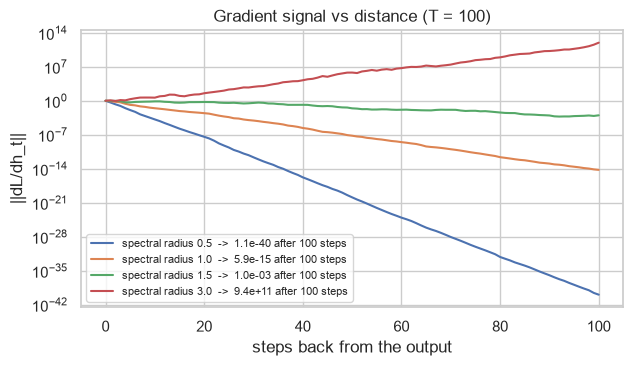

global norm 50 -> scale 0.020 -> clipped norm 1.00 (direction unchanged)


In [6]:
def grad_profile(rho, T=100, H=32, F=4, seed=0):
    r = np.random.default_rng(seed)
    q, _ = np.linalg.qr(r.normal(size=(H, H))); U = rho * q                    # spectral radius exactly rho (orthogonal * rho)
    Wx = r.normal(0, .3, (F, H)); h = np.zeros(H); hs = [h]
    for t in range(T): h = np.tanh(r.normal(size=F) @ Wx + h @ U); hs.append(h)
    g = r.normal(size=H); g /= np.linalg.norm(g); norms = [np.linalg.norm(g)]   # unit gradient at t = T
    for t in range(T, 0, -1): g = (g * (1 - hs[t] ** 2)) @ U.T; norms.append(np.linalg.norm(g))
    return np.array(norms)                                                     # norms[k] = ||dL/dh_{T-k}||

fig, ax = plt.subplots(figsize=(7, 3.6))
for rho in (0.5, 1.0, 1.5, 3.0):
    n_ = grad_profile(rho); ax.semilogy(n_, label=f"spectral radius {rho}  ->  {n_[-1]:.1e} after 100 steps")
ax.set(xlabel="steps back from the output", ylabel="||dL/dh_t||", title="Gradient signal vs distance (T = 100)"); ax.legend(fontsize=8); plt.show()
assert grad_profile(0.5)[-1] < 1e-10 and grad_profile(3.0)[-1] > 1e3

# clipping by global norm
g1, g2 = np.array([30., 0.]), np.array([0., 40.]); tot = np.sqrt((g1 ** 2).sum() + (g2 ** 2).sum()); s = min(1, 1.0 / tot)
print(f"global norm {tot:.0f} -> scale {s:.3f} -> clipped norm {np.sqrt(((g1*s)**2).sum() + ((g2*s)**2).sum()):.2f} (direction unchanged)")
assert abs(np.sqrt(((g1 * s) ** 2).sum() + ((g2 * s) ** 2).sum()) - 1) < 1e-9

## 6. LSTM and GRU: gates

Gates are sigmoid outputs in $(0,1)$ multiplied element-wise onto values. They let the network decide what to keep, write and expose.

**LSTM** has two states, hidden $h_t$ and cell $c_t$ (the long-term memory):

$$\begin{aligned}
i_t&=\sigma(x_tW_i+h_{t-1}U_i+b_i)&&\text{input gate: how much new content to write}\\
f_t&=\sigma(x_tW_f+h_{t-1}U_f+b_f)&&\text{forget gate: how much old memory to keep}\\
g_t&=\tanh(x_tW_g+h_{t-1}U_g+b_g)&&\text{candidate content}\\
o_t&=\sigma(x_tW_o+h_{t-1}U_o+b_o)&&\text{output gate}\\
c_t&=f_t\odot c_{t-1}+i_t\odot g_t&&\text{\textbf{additive} memory update}\\
h_t&=o_t\odot\tanh(c_t)
\end{aligned}$$

The additive update gives $\partial c_t/\partial c_{t-1}=f_t$: if $f_t\approx1$ the gradient passes through unchanged — the cure for vanishing gradients. Numeric feel: $f=0.9,\ c_{t-1}=2,\ i=0.5,\ g=0.4\Rightarrow c_t=0.9\cdot2+0.5\cdot0.4=2.0$.

**GRU** merges the two states: reset $r_t=\sigma(\cdot)$, update $z_t=\sigma(\cdot)$, candidate $n_t=\tanh(x_tW_n+b_{in}+r_t\odot(h_{t-1}U_n+b_{hn}))$, and $h_t=(1-z_t)\odot n_t+z_t\odot h_{t-1}$ — again a convex mix of old and new, so memory can be preserved.

Parameters per layer: vanilla $FH+H^2+H$; GRU **3×** that; LSTM **4×** that (one block per gate/candidate).

In [7]:
F2, H2 = 4, 5; x = torch.randn(1, F2); h = torch.randn(1, H2); cc = torch.randn(1, H2)
sig = torch.sigmoid

# ---- LSTM by hand (PyTorch weight layout: rows stacked as [input, forget, cell(g), output])
lc = nn.LSTMCell(F2, H2); Wi, Ui, bi, bh_ = lc.weight_ih, lc.weight_hh, lc.bias_ih, lc.bias_hh
z = x @ Wi.T + bi + h @ Ui.T + bh_; i_, f_, g_, o_ = z.chunk(4, 1)
i_, f_, g_, o_ = sig(i_), sig(f_), torch.tanh(g_), sig(o_)
c_new = f_ * cc + i_ * g_; h_new = o_ * torch.tanh(c_new)
h_ref, c_ref = lc(x, (h, cc))
print("LSTM  max |by hand - LSTMCell|: h", float((h_new - h_ref).abs().max()), " c", float((c_new - c_ref).abs().max()))
assert torch.allclose(h_new, h_ref, atol=1e-6) and torch.allclose(c_new, c_ref, atol=1e-6)

# ---- GRU by hand (layout [reset, update, new])
gc = nn.GRUCell(F2, H2); gi = x @ gc.weight_ih.T + gc.bias_ih; gh = h @ gc.weight_hh.T + gc.bias_hh
r_i, z_i, n_i = gi.chunk(3, 1); r_h, z_h, n_h = gh.chunk(3, 1)
r = sig(r_i + r_h); zg = sig(z_i + z_h); n = torch.tanh(n_i + r * n_h); h_gru = (1 - zg) * n + zg * h
print("GRU   max |by hand - GRUCell|:", float((h_gru - gc(x, h)).abs().max())); assert torch.allclose(h_gru, gc(x, h), atol=1e-6)

LSTM  max |by hand - LSTMCell|: h 0.0  c 0.0
GRU   max |by hand - GRUCell|: 5.960464477539063e-08


C:\Users\Admin\AppData\Local\Temp\ipykernel_20276\1613370260.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  print("LSTM  max |by hand - LSTMCell|: h", float((h_new - h_ref).abs().max()), " c", float((c_new - c_ref).abs().max()))


## 7. One layer, three names

| Item | Scratch (this assignment) | Keras `SimpleRNN(H)` | PyTorch `nn.RNN(F, H, batch_first=True)` |
|---|---|---|---|
| Input | `(N, T, F)` | `(N, T, F)` | `(N, T, F)` with `batch_first=True` (default is `(T, N, F)`) |
| $W_{xh}$ | `Wxh` $(F,H)$ | `kernel` $(F,H)$ | `weight_ih_l0` $(H,F)$ — transposed |
| $W_{hh}$ | `Whh` $(H,H)$ | `recurrent_kernel` $(H,H)$ | `weight_hh_l0` $(H,H)$ — transposed |
| bias | one vector `bh` | one vector `bias` | **two** vectors `bias_ih_l0`, `bias_hh_l0` (they just add up) |
| output | last state $h_T$ | last state (`return_sequences=False`) | all states; take `out[:, -1]` |
| default init | Glorot input, orthogonal recurrent | same | uniform $\pm1/\sqrt H$ (we overwrite with the scratch weights) |
| gate order (LSTM) | – | $i,f,c,o$ | $i,f,g,o$ (same order, same maths) |
| gate order (GRU) | – | $z,r,h$ | $r,z,n$ — differs, so weights cannot be copied blindly |
| training loop | hand-written BPTT + Adam | `fit()` | hand-written loop with `loss.backward()` |

Different names, same function: the dataset notebooks copy one set of weights into all three and show that the outputs agree to $\sim10^{-7}$.

In [8]:
import os; os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
from tensorflow import keras
F3, H3 = 10, 32
rows = []
for kind, mult in (("RNN", 1), ("GRU", 3), ("LSTM", 4)):
    cell = {"RNN": keras.layers.SimpleRNN, "GRU": keras.layers.GRU, "LSTM": keras.layers.LSTM}[kind](H3)
    km = keras.Sequential([keras.layers.Input((28, F3)), cell]); pm = {"RNN": nn.RNN, "GRU": nn.GRU, "LSTM": nn.LSTM}[kind](F3, H3)
    rows.append(dict(model=kind, keras=km.count_params(), pytorch=sum(p.numel() for p in pm.parameters()), blocks=mult,
                     vanilla_formula_times_blocks=mult * (F3 * H3 + H3 * H3 + H3)))
import pandas as pd; df = pd.DataFrame(rows).set_index("model"); display(df)
print("F = 10, H = 32. PyTorch carries a second bias per block (+H*blocks), and Keras GRU does too (reset_after=True), Keras LSTM / SimpleRNN do not.")
assert df.loc["RNN", "keras"] == 1376 and df.loc["LSTM", "keras"] == 4 * 1376

,keras,pytorch,blocks,vanilla_formula_times_blocks
model,,,,
RNN,1376,1408,1,1376
GRU,4224,4224,3,4128
LSTM,5504,5632,4,5504


F = 10, H = 32. PyTorch carries a second bias per block (+H*blocks), and Keras GRU does too (reset_after=True), Keras LSTM / SimpleRNN do not.


## Summary

* A window of a time series is a tensor `(T, F)`; an RNN folds it into one state with the **same** weights at every step.
* Training uses BPTT: gradients are sums over time and travel through products of $\mathrm{diag}(1-h^2)W_{hh}^\top$ — hence vanishing/exploding gradients and the need for clipping.
* LSTM/GRU replace the multiplicative path by gated, additive memory at the price of 3–4× the parameters.
* Scratch, Keras and PyTorch implement the same equations; they differ in weight layout, number of biases and how much of the loop you write yourself.

Next: `st_sp500.ipynb` (stock returns) and `ec_retail.ipynb` (e-commerce order flow).